In [54]:
import os
import pandas as pd
import json
from PIL import Image
from torch.utils.data import Dataset
from logging import getLogger
from collections import defaultdict
import re
from sentence_transformers import SentenceTransformer
import hdbscan
import spacy
nlp = spacy.load("en_core_web_sm")


In [2]:
annot_df = pd.read_csv("/work/dlclarge2/aliy-vjepa/datasets/BDD-X-Dataset/BDD-X-Annotations_v1.csv")

In [52]:
annot_df.head()

,Input.Video,Answer.1start,Answer.1end,Answer.1action,Answer.1justification,Answer.2start,Answer.2end,Answer.2action,Answer.2justification,Answer.3start,...,Answer.13action,Answer.13justification,Answer.14start,Answer.14end,Answer.14action,Answer.14justification,Answer.15start,Answer.15end,Answer.15action,Answer.15justification
0,https://s3-us-west-2.amazonaws.com/sq8geewpqu/...,0,11.0,The car accelerates,because the light has turned green.,12.0,19.0,The car is moving at a steady speed,because traffic is clear.,20.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,https://s3-us-west-2.amazonaws.com/sq8geewpqu/...,0,16.0,The car is stopped.,The car is at an intersection with a red light.,16.0,20.0,The car is accelerating through the intersection.,The light at the intersection has changed to g...,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,https://s3-us-west-2.amazonaws.com/sq8geewpqu/...,0,20.0,The car accelerates slowly to a maintained speed,because the light has turned green and traffic...,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,https://s3-us-west-2.amazonaws.com/sq8geewpqu/...,0,6.0,The car is driving forward,as traffic flows freely.,7.0,9.0,The car merges into the lane to its left,to get around a slower car in front of it.,10.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,https://s3-us-west-2.amazonaws.com/sq8geewpqu/...,0,12.0,The car is stopped,because the light is red.,13.0,18.0,The car is accelerating,as the light turned green.,19.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [84]:
rules1 = { 
    "decelerate": [r"slow.*down", r"decelerat(es|e|ing|ed)?", r"reduce.*speed", r"slows", "is slowing",r"driv* slowly" ],
    "accelerate": [r"\baccelerat(es|e|ing|ed)?\b", r"speed.*up", r"drives fast", r"driving quick*"],
    "steady_speed": [
    r"steady speed", r"maintain", r"moderate speed", r"stays.*speed", r"drives.*at.*same.*speed",
    r"driving at a constant", r"cruising", r"moving forward.*same speed", r"traveling down.*same lane",r"\bsteady\b",
    r"\bmaintain[s]?\b",
    r"\bdriv(e|ing) (at )?(a )?(steady|constant|normal)? ?speed\b",
    r"\bmov(e|ing) (forward|ahead|down)\b",
    r"\btravelling down\b",
    r"\bdriving down\b",
    r"\bcontinues? (forward|ahead|down)\b",
    "heads down"
    r"\bstays\b",
    r"is not moving"
    ],
    "stop": [r"stop", r"brake", r"pull over", r"pull out", r"traffic light", r"idling", r"halt"],
    "switch_lane": [r"switch.*lane", r"change.*lane", r"merg.*lane", r"shift.*lane", r"move.*lane",    r"\bmove[s]? (slightly )?to the right\b",
    r"\bis moving (slightly )?to the right\b",
    r"\bdrift[s]? (slightly )?right\b",
    r"\bveer[s]? (slightly )?right\b",
    r"\bsteer[s]? (slightly )?right\b",
    r"\bsteer[s]? (slightly )?to the right\b",
    r"\bmove[s]? (slightly )?to the left\b",
    r"\bis moving (slightly )?to the left\b",
    r"\bdrift[s]? (slightly )?left\b",
    r"\bveer[s]? (slightly )?left\b",
    r"\bsteer[s]? (slightly )?left\b",
    r"\bchange[s]? (slightly )?to the right\b"],
    "reverse": [r"reverse", r"back[s]? up", r"backing up", r"backward", r"going backward", r"going back"],
    "turn_right": [
    r"\bturn.*right\b",
    r"\bveer.*right\b",
    r"\bcurve.*right\b",
    r"\bright turn\b",
    r"\bright hand turn\b",
    r"\bmake[s]? (a )?right hand turn\b",
    r"\b(right|right hand) turn\b",
    r"\bturns? to the right\b",
    r"\bturning right\b"
    ],
    "turn_left": [
    r"\bturn.*left\b",
    r"\bveer.*left\b",
    r"\bcurve.*left\b",
    r"\bleft turn\b",
    r"\bleft hand turn\b",
    r"\bmake[s]? (a )?left hand turn\b",
    r"\b(left|left hand) turn\b",
    r"\bturns? to the left\b",
    r"\bturning left\b"
    ],

    "u_turn": [r"u-?turn"],
    "intersection": ["intersection"]
}
#moves left or right is in change lane, is that correct?
# stationary is in stop, is that correct?

def classify_action1(action, rules1):
    action = action.lower()
    for label, patterns in rules1.items():
        for pat in patterns:
            if re.search(pat, action):
                return label
    return "-1" 


In [85]:

# Define class keywords and multiword expressions
ACTION_CLASSES = {
    "decelerate": ["slow down", "decelerate", "reduce speed", "eases off", "reducing speed"],
    "accelerate": ["accelerate", "speed up", "gain speed", "pick up speed", "going quicker"],
    "steady_speed": ["steady speed", "keep speed", "drive normally", "drive steadily", "cruise", "maintain speed", "steadily", "forward", "constant", "moderate", "normal", "safe speed", "even speed", "regular", "continues", "average speed", "is moving"],
    "stop": ["stop", "brake", "red light", "pull over", "halt", "park", "standstill", "stationary", "wait", "still", "never moves", "not moving"],
    "turn_left": ["turn left", "left turn", "veer left", "curve left", "angle left", "leftward", "goes left"],
    "turn_right": ["turn right", "right turn", "veer right", "curve right", "angle right", "rightward", "goes right"],
    "u_turn": ["u-turn", "u turn", "u-turns"],
    "switch_lane": ["switch lane", "merge", "change lane", "shift lane", "moves right", "moves left"],
}


def classify_action2(text):
    doc = nlp(text.lower().strip())
    lemmatized = " ".join([token.lemma_ for token in doc])
    for label, keywords in ACTION_CLASSES.items():
        for kw in keywords:
            if kw in lemmatized:
                return label
    return "-1"


In [86]:
def expand_bddx_actions(df):
    all_rows = []
    
    for idx, row in df.iterrows():
        video_info = row.to_dict()
        for i in range(1, 16):  # Up to 15 actions
            action_col = f"Answer.{i}action"
            start_col = f"Answer.{i}start"
            end_col = f"Answer.{i}end"
            if pd.notna(row.get(action_col)) and str(row[action_col]).strip():
                action_text = str(row[action_col]).strip()
                action_class = classify_action1(action_text, rules1)
                action_class = classify_action2(action_text) if action_class == "-1" else action_class

                # Keep original metadata + add action and class
                new_row = {
                    **{k: v for k, v in video_info.items() if not k.startswith("Answer.")},
                    "action_text": action_text,
                    "action_class": action_class,
                    "start": row.get(start_col, None),
                    "end": row.get(end_col, None),
                }
                all_rows.append(new_row)
    
    return pd.DataFrame(all_rows)

# Example usage:
reformatted_df = expand_bddx_actions(annot_df)
reformatted_df.to_csv("bddx_flattened.csv", index=False)

In [87]:

def get_unique_actions(df):
    actions_set = set()
    for idx, row in df.iterrows():
        for i in range(1, 16):  
            action_key = f"Answer.{i}action"
            if pd.notna(row.get(action_key)):
                action = str(row[action_key]).strip().lower()
                if action:
                    actions_set.add(action)

    return actions_set

##Total actions found: 26538
##Unique actions: 6198
uni_actions = get_unique_actions(annot_df)
print(len(get_unique_actions(annot_df))) 


6198


/tmp/ipykernel_676171/4248541315.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=action_counts.index, y=action_counts.values, palette='viridis')


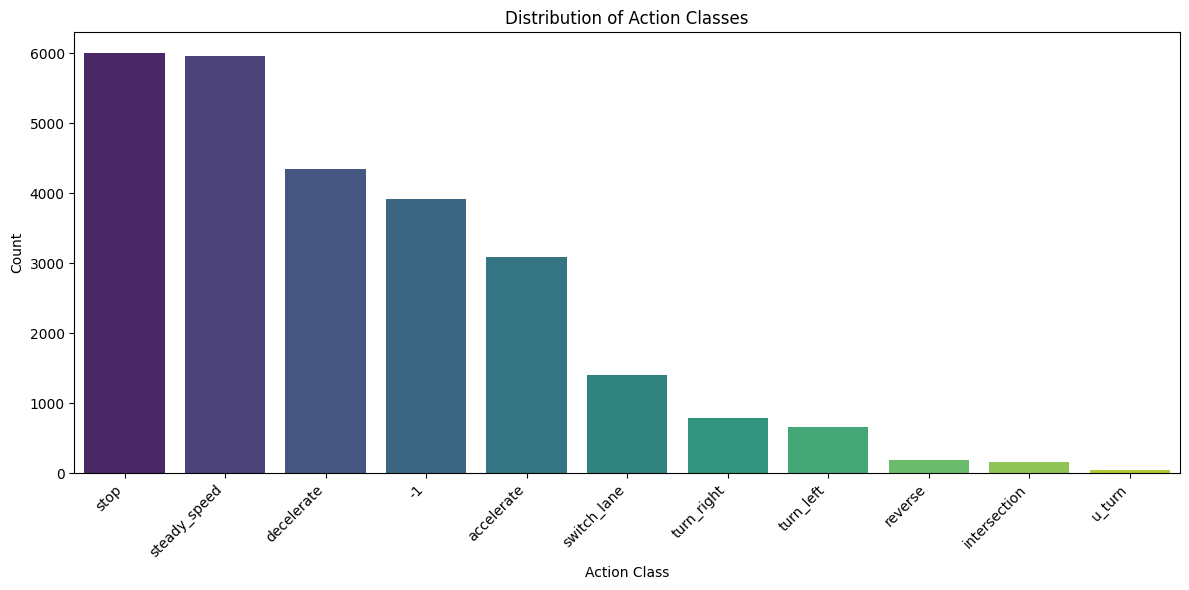

In [88]:
# distribution of actions classes in numbers
import matplotlib.pyplot as plt
import seaborn as sns   
action_counts = reformatted_df['action_class'].value_counts()
plt.figure(figsize=(12, 6))
sns.barplot(x=action_counts.index, y=action_counts.values, palette='viridis')
plt.xticks(rotation=45, ha='right')
plt.title('Distribution of Action Classes')
plt.xlabel('Action Class')
plt.ylabel('Count')
plt.tight_layout()

In [89]:
action_counts

action_class
stop            5998
steady_speed    5963
decelerate      4338
-1              3910
accelerate      3090
switch_lane     1397
turn_right       788
turn_left        661
reverse          192
intersection     164
u_turn            37
Name: count, dtype: int64

In [25]:
action_texts = list(uni_actions)
action_texts

['the vehicle is maintaining its lane',
 'the car slowly edges forward',
 'the car goes left around a line of cars',
 'the car slows down in the middle of its left turn',
 'the car turns right and accelerates down the road',
 'the car remains stopped.',
 'the car is double-parked on the right side of the city street',
 'the car drives slowly down the one-way residential street',
 'the car takes off again',
 'the car drives a little to the left',
 'the car is stopped at the curb',
 'the car heads down into the road',
 'the car is making a slight left',
 'the car drives forward with its windshield wipers on',
 'the car is moving forward to the left a little',
 'the car switches to the right lane while going through an intersection',
 'the car stops turning',
 'the car is parked at the right curb of a busy city street',
 'the car really slows down',
 'the car comes to a quick stop',
 'the car starts to edge forward and stops again.',
 'the car is now driving onto the original street',
 't

In [ ]:
rules = {
    "decelerate": [r"slow.*down", r"decelerat(es|e|ing|ed)?", r"reduce.*speed"],
    "accelerate": [r"\baccelerat(es|e|ing|ed)?\b", r"speed.*up", r"drives fast", r"driving quickly"],
    "steady_speed": [
        r"steady speed", r"maintain", r"moderate speed", r"stays.*speed", r"drives.*at.*same.*speed",
        r"driving at a constant", r"cruising", r"moving forward.*same speed", r"traveling down.*same lane"
    ],
    "stop": [r"stop", r"brake", r"pull over", r"pull out", r"traffic light", r"idling", r"halt"],
    "switch_lane": [r"switch.*lane", r"change.*lane", r"merg.*lane", r"shift.*lane", r"move.*lane"],
    "turn_right": [r"turn.*right", r"veer.*right", r"curve.*right", "right turn"],
    "turn_left": [r"turn.*left", r"veer.*left", r"curve.*left", "left turn"],
    "u_turn": [r"u-?turn"],
    "intersection": ["intersection"]
}

# Preprocessing and classification function
def classify_action(action, rules):
    action = action.lower()
    for label, patterns in rules.items():
        for pat in patterns:
            if re.search(pat, action):
                return label
    return "-1" 

# Classify actions into categories
class_dict = defaultdict(list)
for action in action_texts:
    label = classify_action(action, rules)
    class_dict[label].append(action)




In [46]:
for k, v in class_dict.items():
    print(f"\nClass: {k}, {len(v)} actions")
    for a in v:
        print(" -", a)


Class: steady_speed, 103 actions
 - the vehicle is maintaining its lane
 - the car is driving at a moderate speed in the right lane
 - the car drives at a steady speed
 - the car continues to drive at a steady speed
 - the car maintains speed and lane
 - the cars is travelling down the road at night and stays in the same lane going the same speed.
 - the car stays at a steady speed
 - the vehicle is moving along maintaining the current lane
 - the car is driving down the highway at a steady speed.
 - the car is driving at a constant slow speed
 - the car continues down the road at a steady speed
 - the car drives a moderate speed down the road
 - the car maintains a constant speed and spacing with the vehicle ahead
 - the car is going down the road at a steady speed.
 - the car maintains spacing with the vehicle ahead.
 - the car moves down the street at a moderate speed
 - the car is cruising down the highway
 - the car drove at a slow but steady speed
 - the vehicle is cruising down

In [47]:
import spacy
from collections import defaultdict

nlp = spacy.load("en_core_web_sm")

# Define class keywords and multiword expressions
ACTION_CLASSES = {
    "decelerate": ["slow down", "decelerate", "reduce speed", "eases off", "reducing speed"],
    "accelerate": ["accelerate", "speed up", "gain speed", "pick up speed"],
    "steady_speed": ["steady speed", "keep speed", "drive normally", "drive steadily", "cruise", "maintain speed", "steadily", "forward", "constant", "moderate", "normal", "safe speed", "even speed", "regular"],
    "stop": ["stop", "brake", "red light", "pull over", "halt", "park", "standstill", "stationary", "wait", "still", "never moves", "not moving"],
    "turn_left": ["turn left", "left turn", "veer left", "curve left", "angle left", "leftward", "goes left"],
    "turn_right": ["turn right", "right turn", "veer right", "curve right", "angle right", "rightward", "goes right"],
    "u_turn": ["u-turn", "u turn", "u-turns"],
    "switch_lane": ["switch lane", "merge", "change lane", "shift lane", "moves right", "moves left"],
}


def preprocess_action(text):
    return nlp(text.lower().strip())

def classify_action(text):
    doc = preprocess_action(text)
    lemmatized = " ".join([token.lemma_ for token in doc])
    for label, keywords in ACTION_CLASSES.items():
        for kw in keywords:
            if kw in lemmatized:
                return label
    return "-1"

# Apply to your actions
def classify_all_actions(actions):
    classified = defaultdict(list)
    for action in actions:
        cls = classify_action(action)
        classified[cls].append(action)
    return classified

In [49]:
sec_trial = classify_all_actions(class_dict["-1"])
for k, v in sec_trial.items():
    print(f"\nClass: {k}, {len(v)} actions")
    for a in v:
        print(" -", a)


Class: steady_speed, 678 actions
 - the car slowly edges forward
 - the car drives forward with its windshield wipers on
 - the car is moving forward to the left a little
 - the car is steering to the right and driving forward slowly
 - the car drives forward through the red light
 - the car pulls forward again.
 - the car is rolling forward a few feet very slowly
 - the car moves forward then swerves around two cars
 - the car drives forward making a left hand turn.
 - the car is driving again at almost normal speed.
 - the car begins moving forward then merges right
 - the car starts moving forward
 - the car drives forward slowly and makes a right hand turn
 - the car move forward a short distance.
 - the car moves forward at a slow pace
 - the car continues forward in the left lane
 - the car is driving forward above the speed limit
 - the car glides forward
 - the car begins to move and approaches normal speed
 - the car begins to slowly move forward
 - the car rolls slowly forwa

In [50]:
del class_dict["-1"]
# merge two dictionaries
for k, v in sec_trial.items():
    class_dict[k].extend(v)

In [51]:
for k, v in class_dict.items():
    print(f"\nClass: {k}, {len(v)} actions")
    for a in v:
        print(" -", a)


Class: steady_speed, 781 actions
 - the vehicle is maintaining its lane
 - the car is driving at a moderate speed in the right lane
 - the car drives at a steady speed
 - the car continues to drive at a steady speed
 - the car maintains speed and lane
 - the cars is travelling down the road at night and stays in the same lane going the same speed.
 - the car stays at a steady speed
 - the vehicle is moving along maintaining the current lane
 - the car is driving down the highway at a steady speed.
 - the car is driving at a constant slow speed
 - the car continues down the road at a steady speed
 - the car drives a moderate speed down the road
 - the car maintains a constant speed and spacing with the vehicle ahead
 - the car is going down the road at a steady speed.
 - the car maintains spacing with the vehicle ahead.
 - the car moves down the street at a moderate speed
 - the car is cruising down the highway
 - the car drove at a slow but steady speed
 - the vehicle is cruising down

## dataframe gathering

In [1]:
import pandas as pd
import json
import os
pd.set_option('display.max_colwidth', None)

In [ ]:
df_gathered = pd.read_csv("bddx_with_local_paths_dedup.csv")
df_gathered["local_path"].isna().sum()

In [ ]:
group = df_gathered.groupby("Input.Video")["local_path"].apply(lambda x: x.isna().all() or (x == "" ).all()) 
group.sum() #number of missing videos in BDD-X 
#originally there are 6999 videos

np.int64(1573)

In [5]:
# check if there any nans in every column 
cleaned = pd.read_csv("filtered_bddx_clean_6classes.csv")
nann = cleaned.isna().sum()
cleaned[cleaned["start"].isna() | cleaned["end"].isna()] 
#print(nann[nann > 0])


,local_path,action_class,start,end
1618,/data/nxtaimraid02/datasets/BDD100K/videos/unzipped_files/train/bdd100k_videos_train_02/bdd100k/videos/train/06257efc-9aba5724.mov,steady_speed,31.0,NaN


In [2]:
jep = pd.read_csv("/work/dlclarge2/aliy-vjepa/vjepa2/notebooks/bddx_vjepa2_format_6classes_updated.csv", header=None, delimiter=" ")

In [5]:
# split the data into train, val of 80% for training and 20% for validation for each class action
from sklearn.model_selection import train_test_split


train_list = []
val_list = []

for action_class, group in jep.groupby(1):
    train, val = train_test_split(group, test_size=0.2, random_state=42, shuffle=True)
    train_list.append(train)
    val_list.append(val)

train_df = pd.concat(train_list).reset_index(drop=True)
val_df = pd.concat(val_list).reset_index(drop=True)

train_df.to_csv("bddx_train_split.csv", index=False, header=False, sep=" ")
val_df.to_csv("bddx_val_split.csv", index=False, header=False, sep=" ")

print(f"Train size: {len(train_df)}, Val size: {len(val_df)}")

Train size: 12928, Val size: 3236


In [7]:
(jep[2] >= jep[3]).sum()

np.int64(0)

In [12]:
jep.isna().sum()

0    0
1    0
2    0
3    1
dtype: int64

action_class
stop            28.864014
steady_speed    28.593394
decelerate      20.948398
accelerate      15.000923
turn_right       3.591857
turn_left        3.001415
Name: count, dtype: float64
start    3
end      9
dtype: int64
local_path      0
action_class    0
start           3
end             9
dtype: int64


/tmp/ipykernel_1949831/1240738675.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=action_counts.index, y=action_counts.values, palette='viridis')


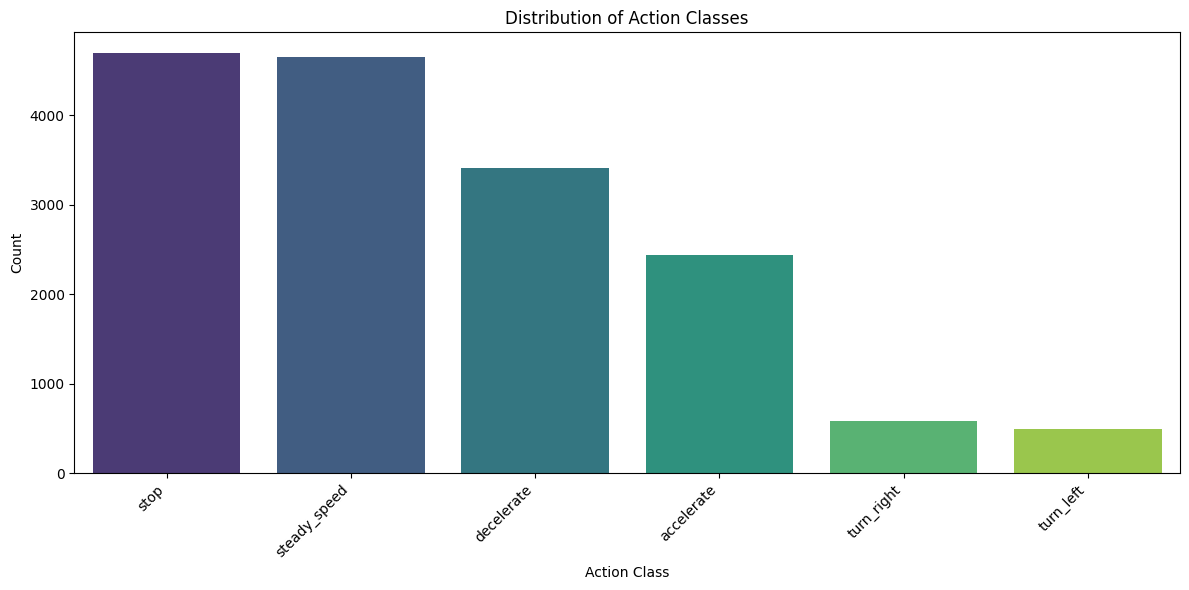

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns   
action_counts = pd.read_csv("filtered_bddx_clean_6classes.csv")['action_class'].value_counts()
# print the percentage of each action class
action_counts_percentage = action_counts / action_counts.sum() * 100
print(action_counts_percentage)
plt.figure(figsize=(12, 6))
sns.barplot(x=action_counts.index, y=action_counts.values, palette='viridis')
plt.xticks(rotation=45, ha='right')
plt.title('Distribution of Action Classes')
plt.xlabel('Action Class')
plt.ylabel('Count')
plt.tight_layout()

In [4]:
orig = pd.read_csv("/work/dlclarge2/aliy-vjepa/datasets/BDD-X-Dataset/BDD-X-Annotations_v1.csv")
orig.head()


,Input.Video,Answer.1start,Answer.1end,Answer.1action,Answer.1justification,Answer.2start,Answer.2end,Answer.2action,Answer.2justification,Answer.3start,...,Answer.13action,Answer.13justification,Answer.14start,Answer.14end,Answer.14action,Answer.14justification,Answer.15start,Answer.15end,Answer.15action,Answer.15justification
0,https://s3-us-west-2.amazonaws.com/sq8geewpqu/...,0,11.0,The car accelerates,because the light has turned green.,12.0,19.0,The car is moving at a steady speed,because traffic is clear.,20.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,https://s3-us-west-2.amazonaws.com/sq8geewpqu/...,0,16.0,The car is stopped.,The car is at an intersection with a red light.,16.0,20.0,The car is accelerating through the intersection.,The light at the intersection has changed to g...,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,https://s3-us-west-2.amazonaws.com/sq8geewpqu/...,0,20.0,The car accelerates slowly to a maintained speed,because the light has turned green and traffic...,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,https://s3-us-west-2.amazonaws.com/sq8geewpqu/...,0,6.0,The car is driving forward,as traffic flows freely.,7.0,9.0,The car merges into the lane to its left,to get around a slower car in front of it.,10.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,https://s3-us-west-2.amazonaws.com/sq8geewpqu/...,0,12.0,The car is stopped,because the light is red.,13.0,18.0,The car is accelerating,as the light turned green.,19.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
#orig[~orig["Input.Video"].astype(str).str.contains("samples-1k", na=False)]
orig["Input.Video"].dropna().astype(str).apply(lambda x: "samples-1k" not in x).sum()

np.int64(5999)

## cancel the following

In [ ]:

nlp = spacy.load("en_core_web_sm")

def classify_action(action: str) -> str:
    action = action.lower().strip()
    doc = nlp(action)

    # Normalize
    tokens = set([token.lemma_ for token in doc])

    if "reverse" in tokens or "back" in action:
        return "reverse"
    if any(x in action for x in ["not moving", "no longer moving", "remains still", "has not moved", "sits", "sitting"]):
        return "stationary"
    if any(x in tokens for x in ["drive", "travel", "move", "head", "go", "proceed", "continue", "resume"]):
        if "curve" in tokens or "bend" in tokens:
            return "curving"
        elif "intersection" in tokens:
            return "intersection_pass"
        else:
            return "drive_normal"
    if "swerve" in tokens or "drift" in tokens or "pull" in tokens:
        return "lane_adjust"
    return "uncertain"

In [33]:
third_trial = defaultdict(list)
for action in grouped["-1"]:
    label = classify_action(action)
    third_trial[label].append(action)

In [34]:
for k, v in third_trial.items():
    print(f"\nClass: {k}, {len(v)} actions")
    for a in v:
        print(" -", a)


Class: drive_normal, 566 actions
 - the car now moves straight
 - the car proceeds ahead down the road
 - the car moves up a few feet
 - the car is traveling down the dimly lit highway
 - the car continues again
 - the car heads down road
 - the car drives down the street.
 - the car starts to move
 - the car drives a little to the left
 - the car is moving
 - the car is travelling down the street
 - the car proceeds ahead down the highway
 - the car is continuing down the city street
 - the car is beginning to move
 - the driver heads down the street
 - the car moves right
 - the car is moving to the left.
 - the car is able to drive freely down the street
 - the car travels down a narrow city street
 - the car starts to move again
 - the car moves slightly to the left again
 - the car is now driving straight
 - the vehicle continues down the road
 - the car continues at a reasonable speed
 - the car drives through a roundabout
 - the car moves down the street
 - the car moves straig

In [35]:
del grouped["-1"]
# merge two dictionaries
for k, v in third_trial.items():
    grouped[k].extend(v)


In [36]:
for k, v in grouped.items():
    print(f"\nClass: {k}, {len(v)} actions")
    for a in v:
        print(" -", a)


Class: lane_change, 758 actions
 - the car reduces its speed as it merges onto another road
 - the car travels in the right lane of the highway at night
 - the vehicle moved into the right lane
 - the car moved into another lane on the left
 - the car drives down the middle lane of a highway
 - the car moves back into the left lane
 - the car steers partially into the oncoming lane of traffic to its left
 - the car is merging into the left turn lane
 - the car pulls back into the proper lane
 - the car is merging back into the left lane
 - the car goes onto the right lane
 - the car begins merging right
 - the car continues forward in the left lane
 - the car is merging all the way right
 - the car is changing lanes to the leftmost lane
 - the car travels with the speed of traffic in the left lane of the exit lanes
 - the car is switching lanes
 - the car starts to move back over to the right lane
 - the car is merging into the left lane
 - the car veers to the left and changes lanes


In [11]:
print(df[:])

                                                action
0                             the car brakes to a stop
1                       the car is continuing straight
2                      the car makes an immediate left
3              the car merges right then moves forward
4     the car is parked at the terminal at the airport
...                                                ...
6193                          the car is again stopped
6194          the car moves over one lane to the right
6195           the car is waiting at the traffic light
6196                      the car slowly edges forward
6197                       the car edges forward a bit

[6198 rows x 1 columns]


In [5]:

model = SentenceTransformer("all-mpnet-base-v2")

In [ ]:
embeddings = model.encode(action_texts, show_progress_bar=True)

Batches:   0%|          | 0/194 [00:00<?, ?it/s]

In [ ]:
clusterer = hdbscan.HDBSCAN(min_cluster_size=5)
cluster_ids = clusterer.fit_predict(embeddings)

/work/dlclarge2/aliy-maskgit/miniconda3/envs/vjepa2/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/work/dlclarge2/aliy-maskgit/miniconda3/envs/vjepa2/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [ ]:
from collections import defaultdict

clusters = defaultdict(list)
for text, cluster_id in zip(action_texts, cluster_ids):
    clusters[cluster_id].append(text)

for cid, phrases in clusters.items():
    print(f"\n=== Cluster {cid} ===")
    for p in phrases:  
        print("-", p)


=== Cluster -1 ===
- the car continues driving normally
- the car progresses forward
- the car drives down the street at a moderate rate of speed
- the vehicle is moving at a slow pace in the right lane
- the car is starting to roll forward
- the car is moving freely down a dark, snow-lined street
- the car is driving on the left turn lane
- the car is pulled over on the right side of a city street
- the car proceeds slowly and cautiously down the street
- the car is moving down the road carefully
- the car slowly drives straight
- the car is stopping at the edge of the intersection.
- the car drives right slightly
- the car partially moves into the turn lane
- the car is gradually steering right.
- the car is moving left
- the car drives to the left a bit
- the car moves forward and right slowly
- the car is moving slowly in the left lane of the highway
- the car is completely motionless
- the car slows and maintains spacing
- the car drastically slows
- the car accelerates down the 